In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("/content/credit_risk_dataset.csv")

In [4]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
df.shape

(32581, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [7]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [8]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [19]:
missing = df.isnull().sum()

missing[missing > 0]

,0
person_emp_length,887
loan_int_rate,3095


In [9]:
 print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 165


In [20]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent[missing_percent > 0]

,0
person_emp_length,2.736303
loan_int_rate,9.547754


In [21]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


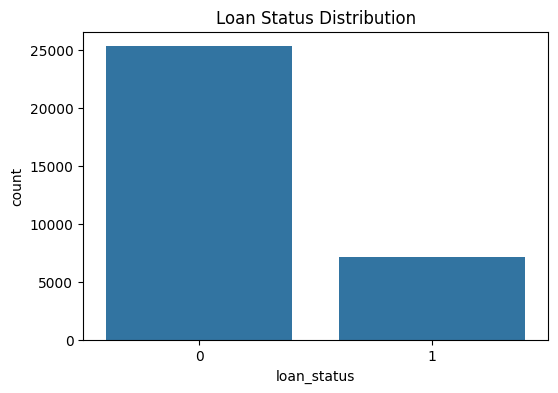

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x="loan_status", data=df)

plt.title("Loan Status Distribution")
plt.show()

In [12]:
df["loan_status"].value_counts()

,count
loan_status,
0,25327
1,7089


In [13]:
numeric_cols = df.select_dtypes(include=np.number).columns

numeric_cols

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length'],
      dtype='object')

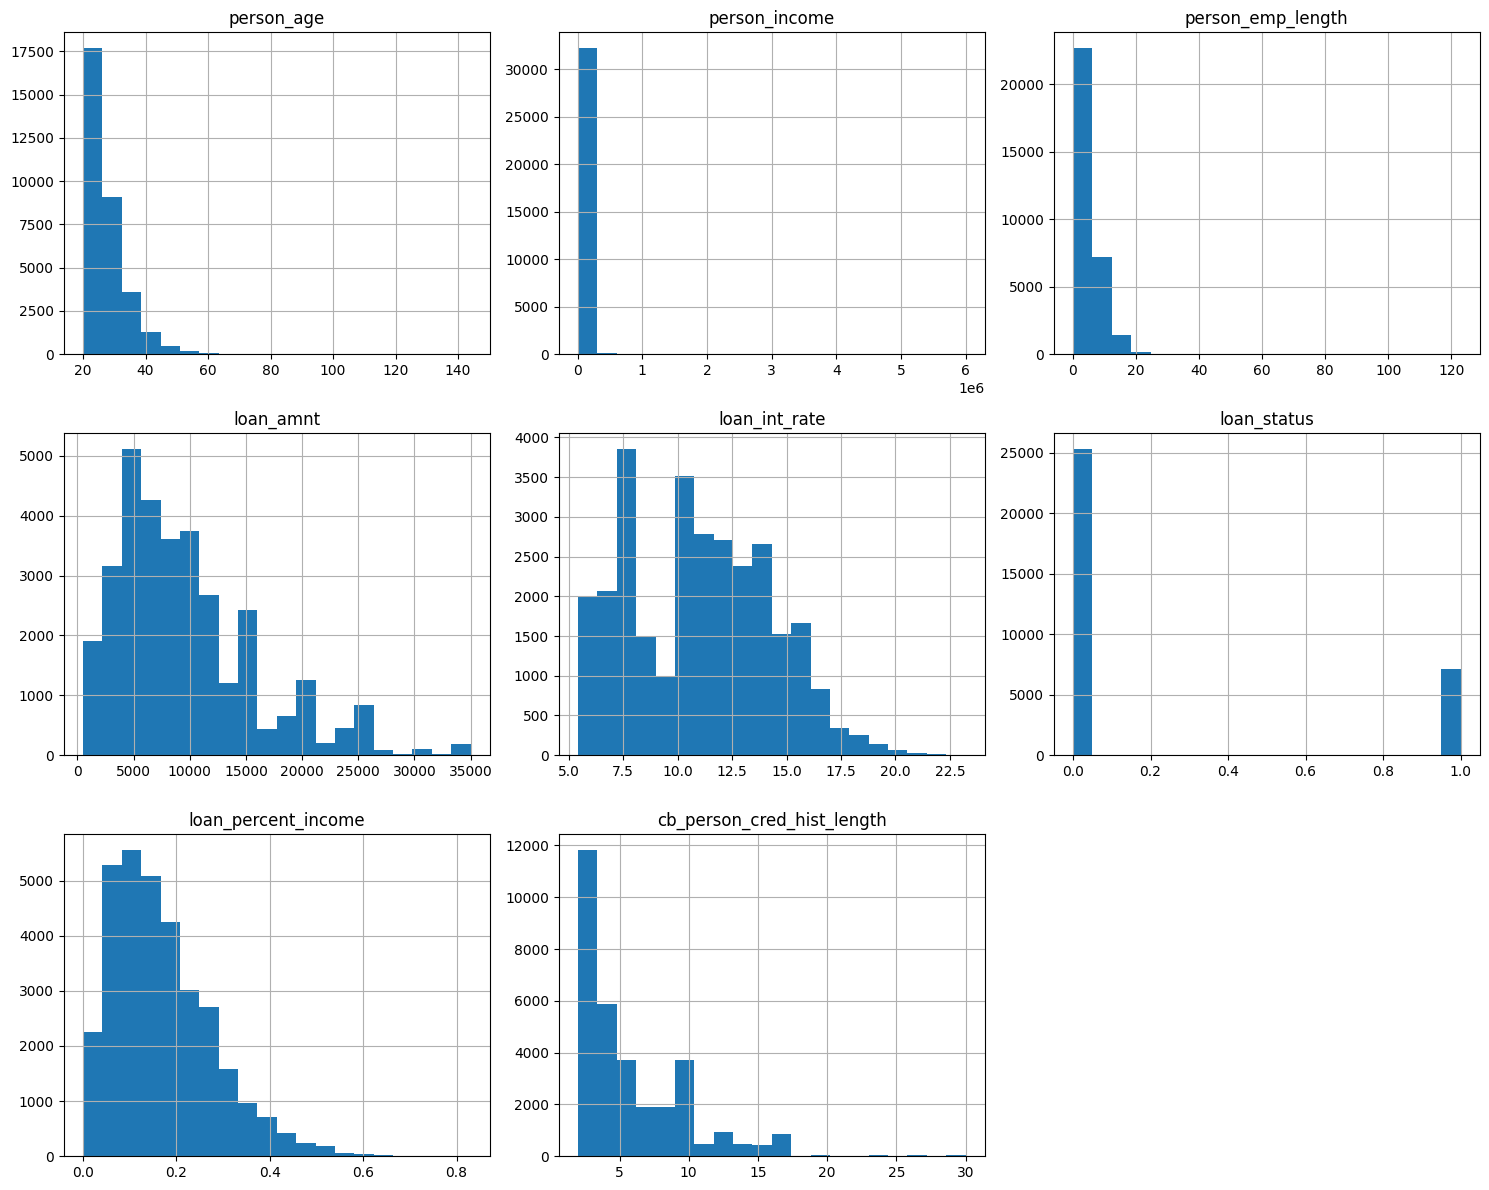

In [14]:
df[numeric_cols].hist(figsize=(15,12), bins=20)

plt.tight_layout()

plt.show()

In [23]:
num_cols = df.select_dtypes(include=np.number).columns

cat_cols = df.select_dtypes(include="object").columns

print("Numerical Columns")
print(num_cols)

print("\nCategorical Columns")
print(cat_cols)

Numerical Columns
Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length'],
      dtype='object')

Categorical Columns
Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')


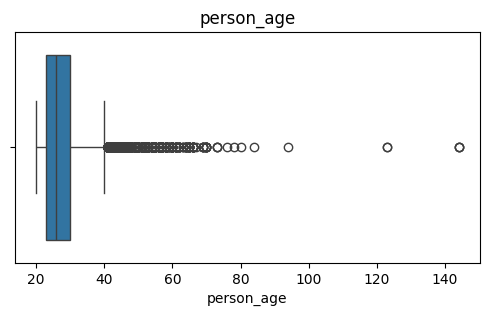

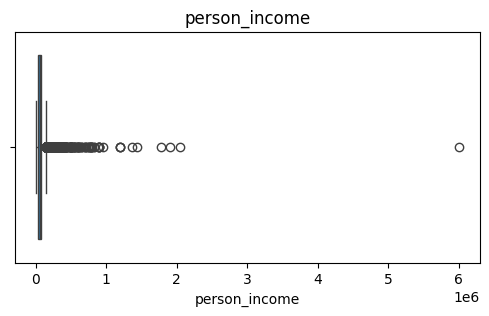

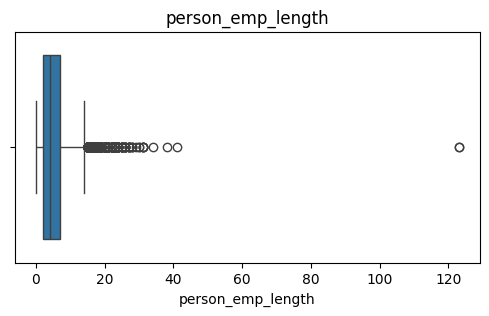

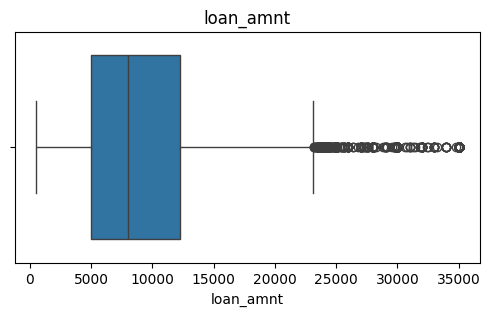

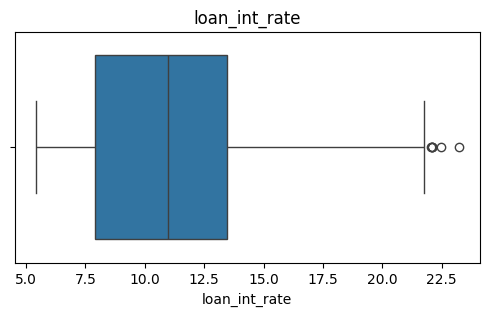

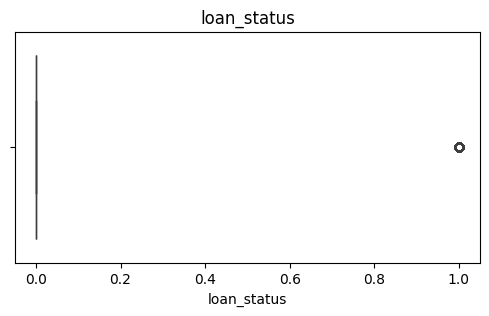

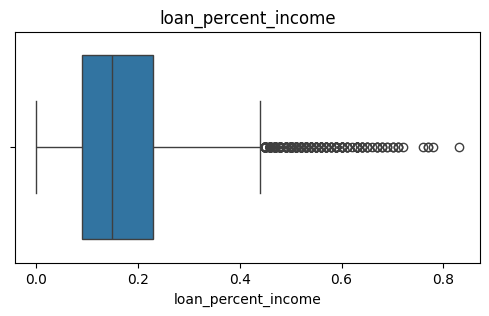

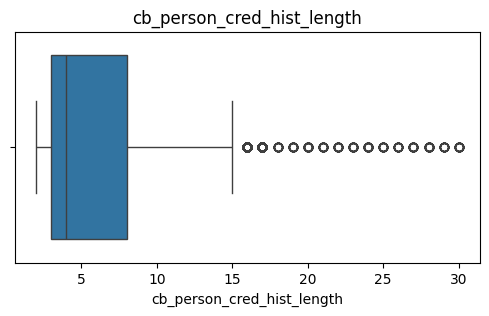

In [15]:
for col in numeric_cols:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

In [16]:
categorical_cols = df.select_dtypes(include="object").columns

categorical_cols

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')

In [17]:
for col in categorical_cols:

    print(col)

    print(df[col].value_counts())

    print("-"*40)

person_home_ownership
person_home_ownership
RENT        16378
MORTGAGE    13369
OWN          2563
OTHER         106
Name: count, dtype: int64
----------------------------------------
loan_intent
loan_intent
EDUCATION            6411
MEDICAL              6042
VENTURE              5682
PERSONAL             5498
DEBTCONSOLIDATION    5189
HOMEIMPROVEMENT      3594
Name: count, dtype: int64
----------------------------------------
loan_grade
loan_grade
A    10703
B    10387
C     6438
D     3620
E      963
F      241
G       64
Name: count, dtype: int64
----------------------------------------
cb_person_default_on_file
cb_person_default_on_file
N    26686
Y     5730
Name: count, dtype: int64
----------------------------------------


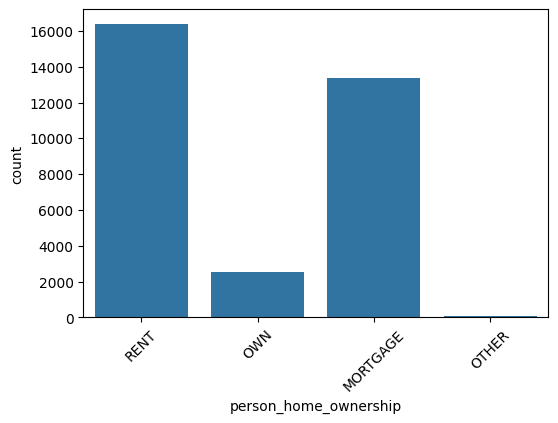

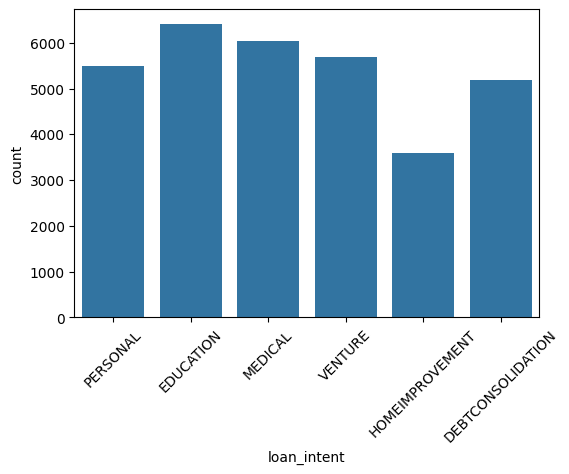

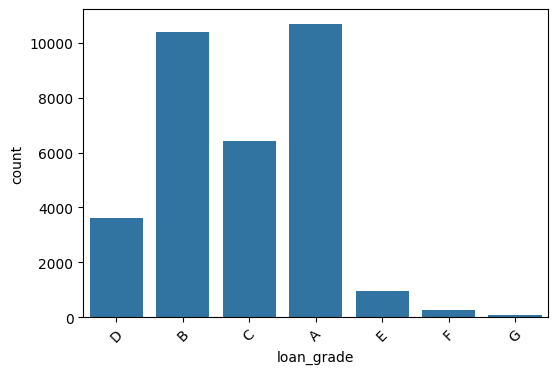

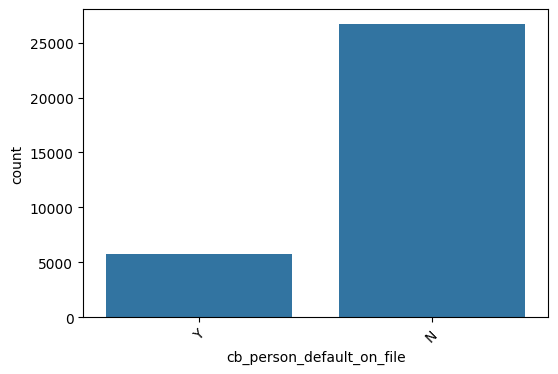

In [18]:
for col in categorical_cols:

    plt.figure(figsize=(6,4))

    sns.countplot(x=col, data=df)

    plt.xticks(rotation=45)

    plt.show()

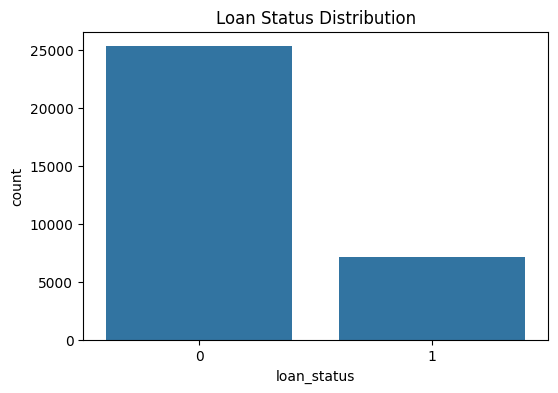

loan_status
0    25327
1     7089
Name: count, dtype: int64


In [24]:
plt.figure(figsize=(6,4))

sns.countplot(x="loan_status", data=df)

plt.title("Loan Status Distribution")

plt.show()

print(df["loan_status"].value_counts())

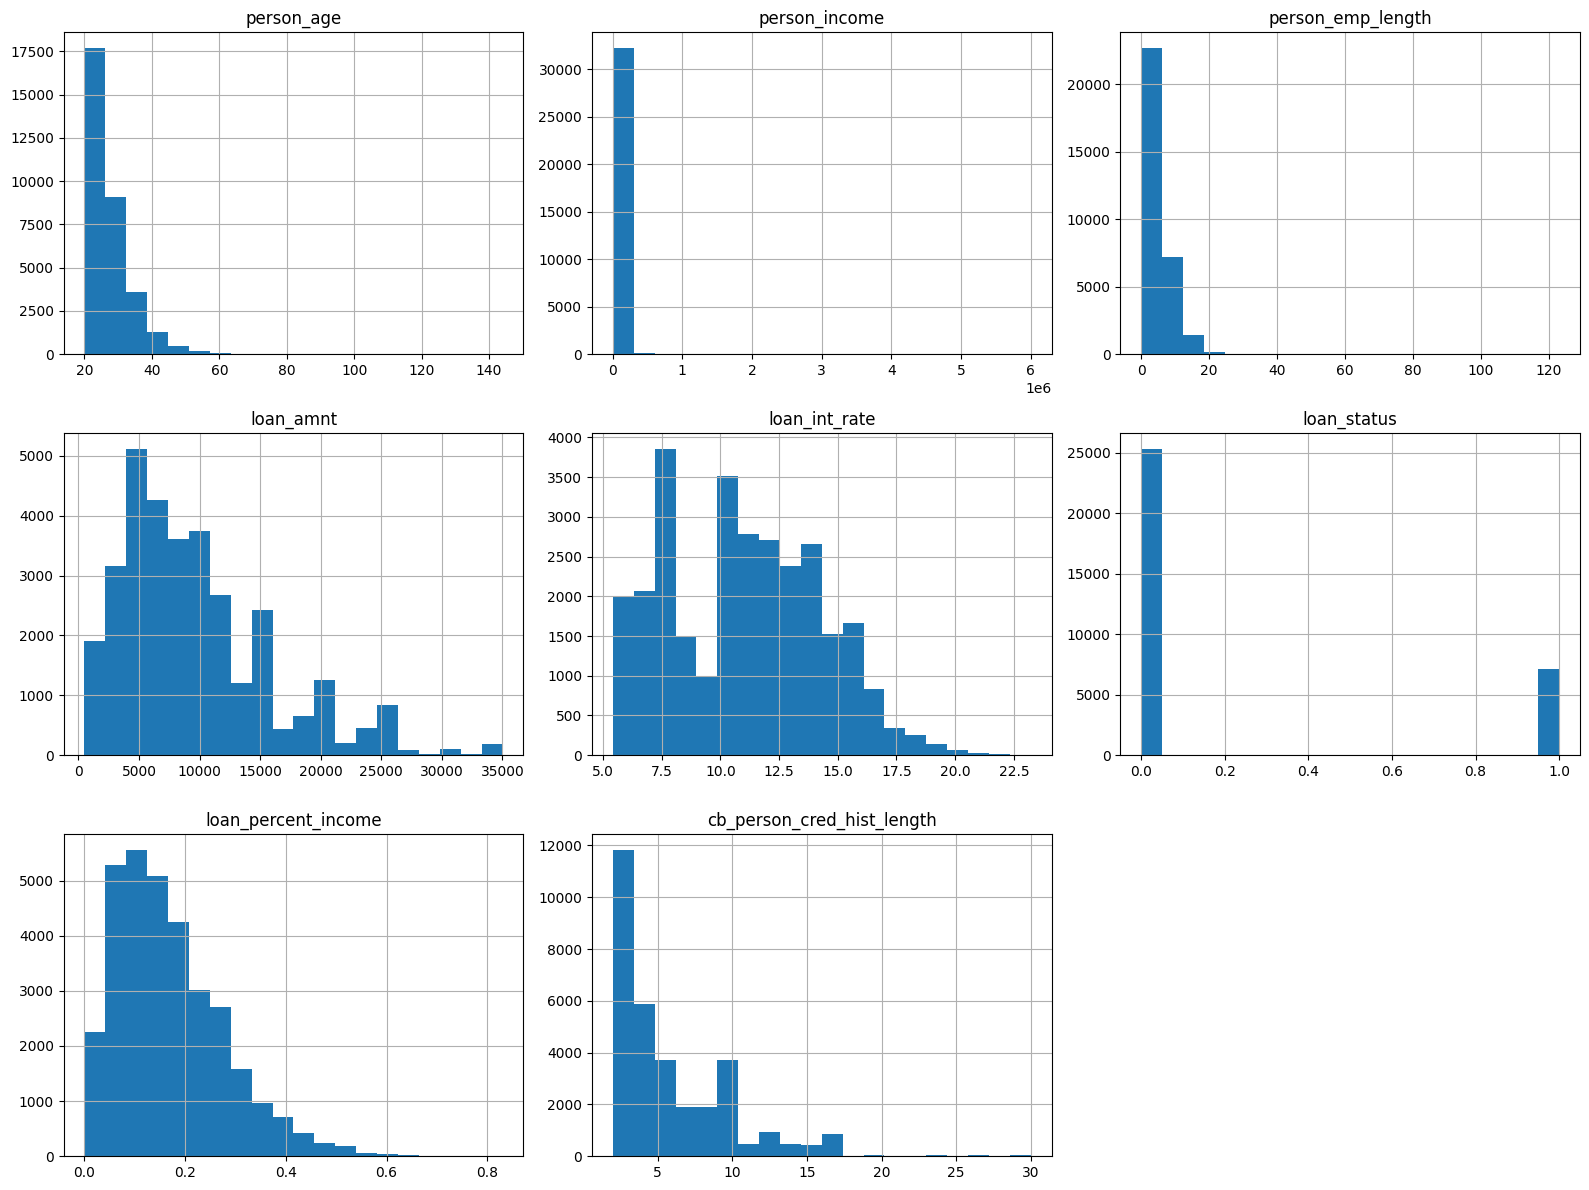

In [25]:
df[num_cols].hist(figsize=(16,12), bins=20)

plt.tight_layout()

plt.show()

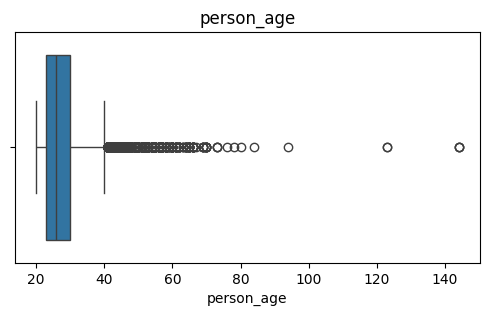

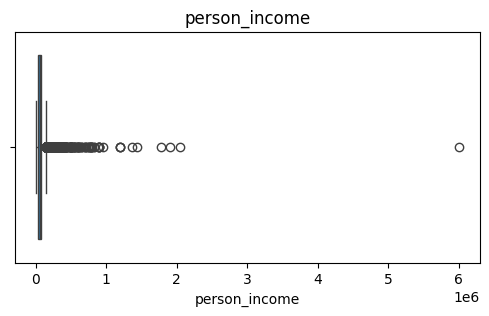

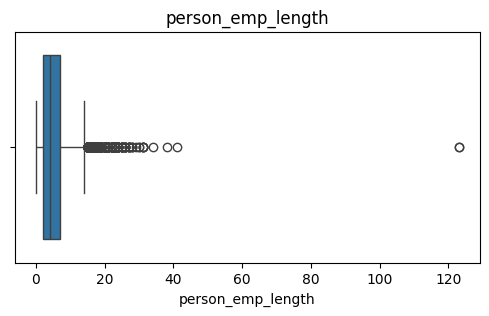

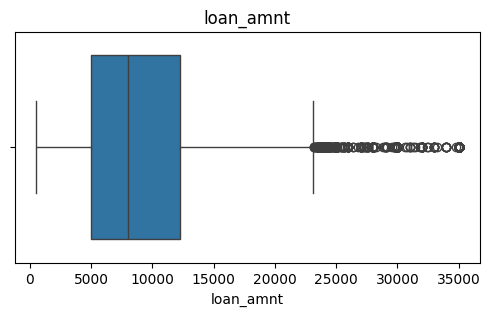

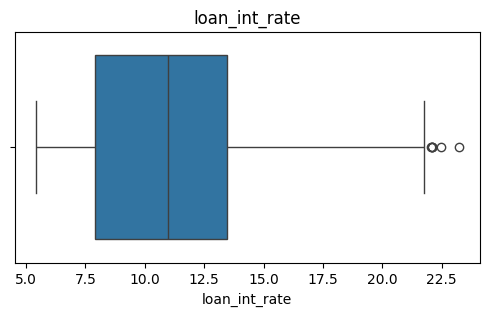

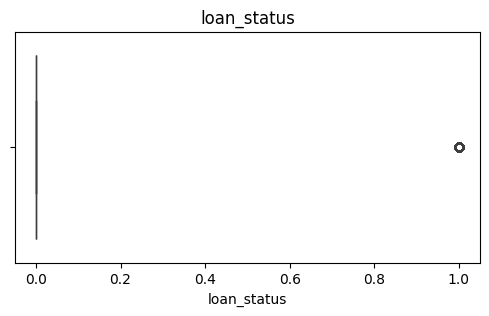

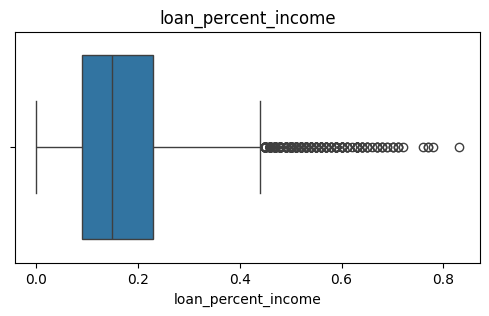

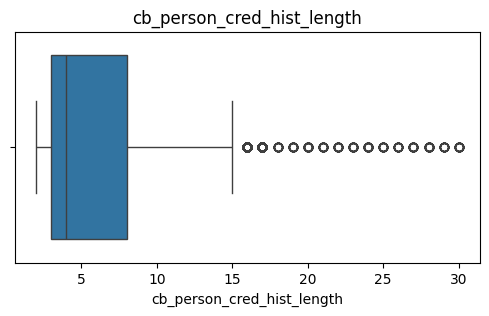

In [26]:
for col in num_cols:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

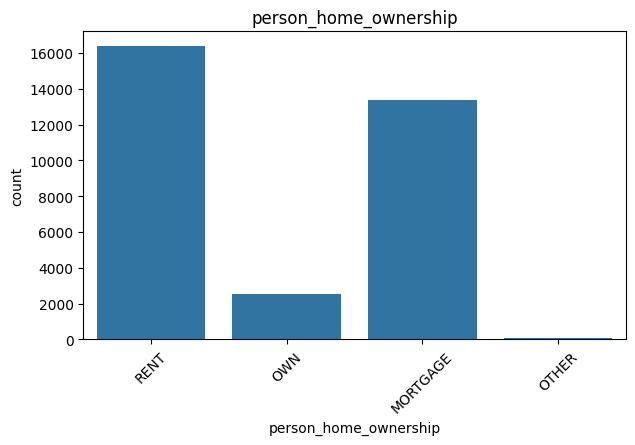

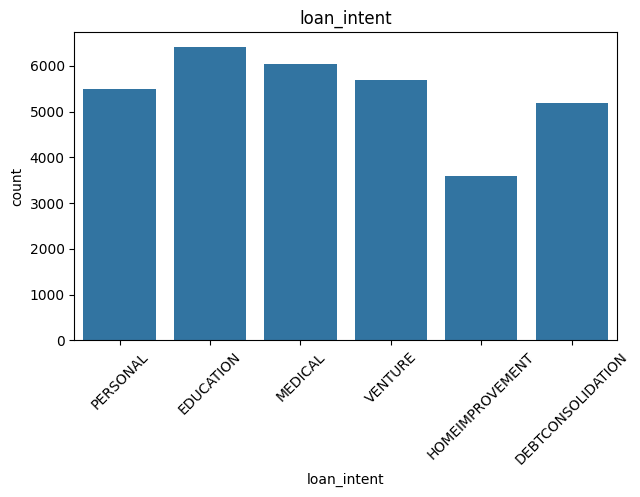

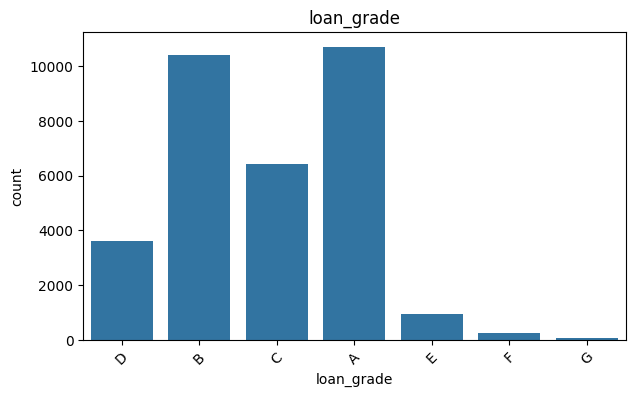

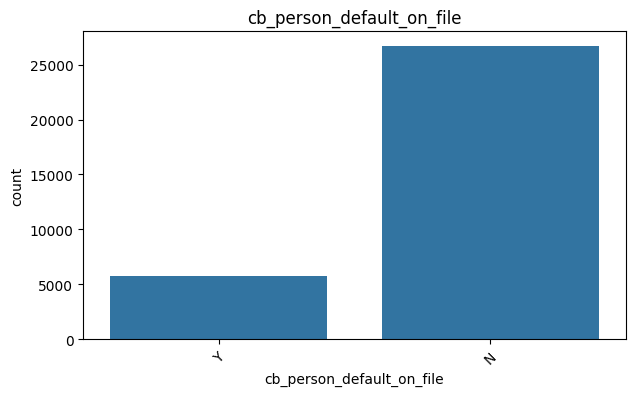

In [27]:
for col in cat_cols:

    plt.figure(figsize=(7,4))

    sns.countplot(x=col, data=df)

    plt.xticks(rotation=45)

    plt.title(col)

    plt.show()

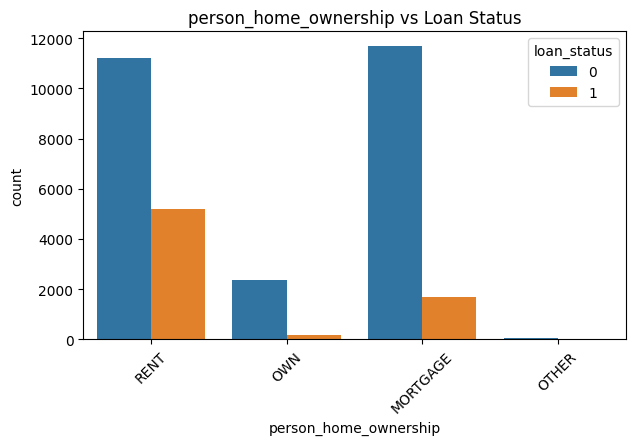

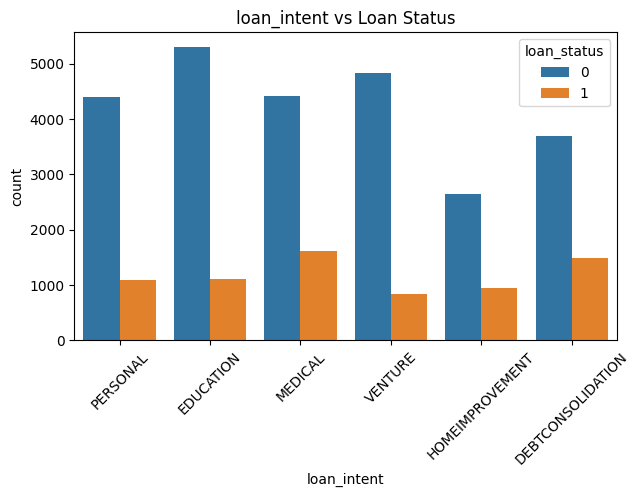

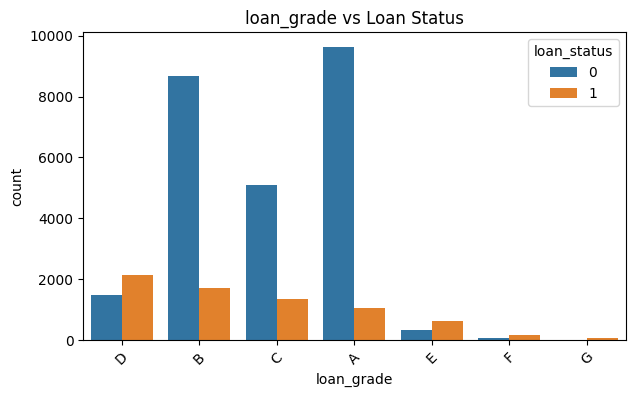

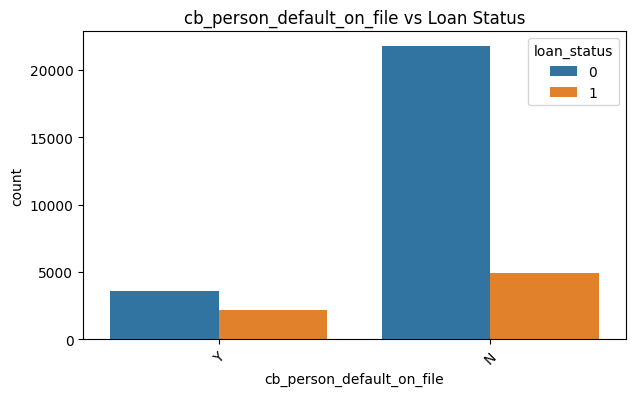

In [28]:
for col in cat_cols:

    plt.figure(figsize=(7,4))

    sns.countplot(x=col, hue="loan_status", data=df)

    plt.xticks(rotation=45)

    plt.title(f"{col} vs Loan Status")

    plt.show()

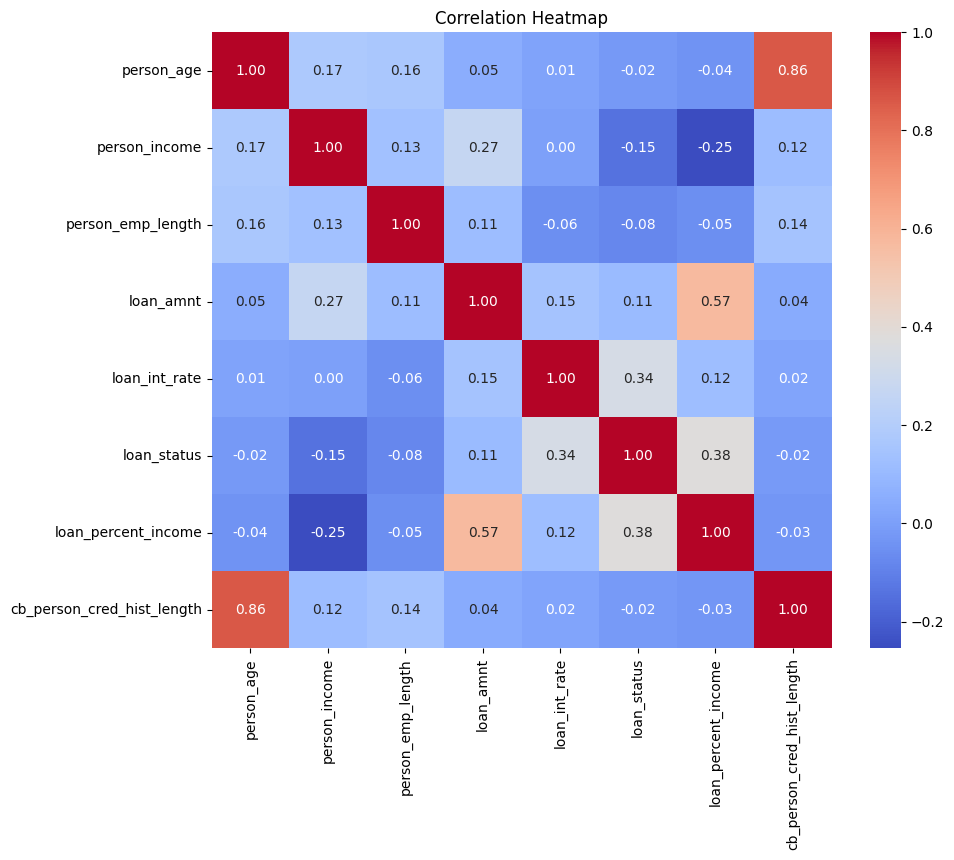

In [29]:
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

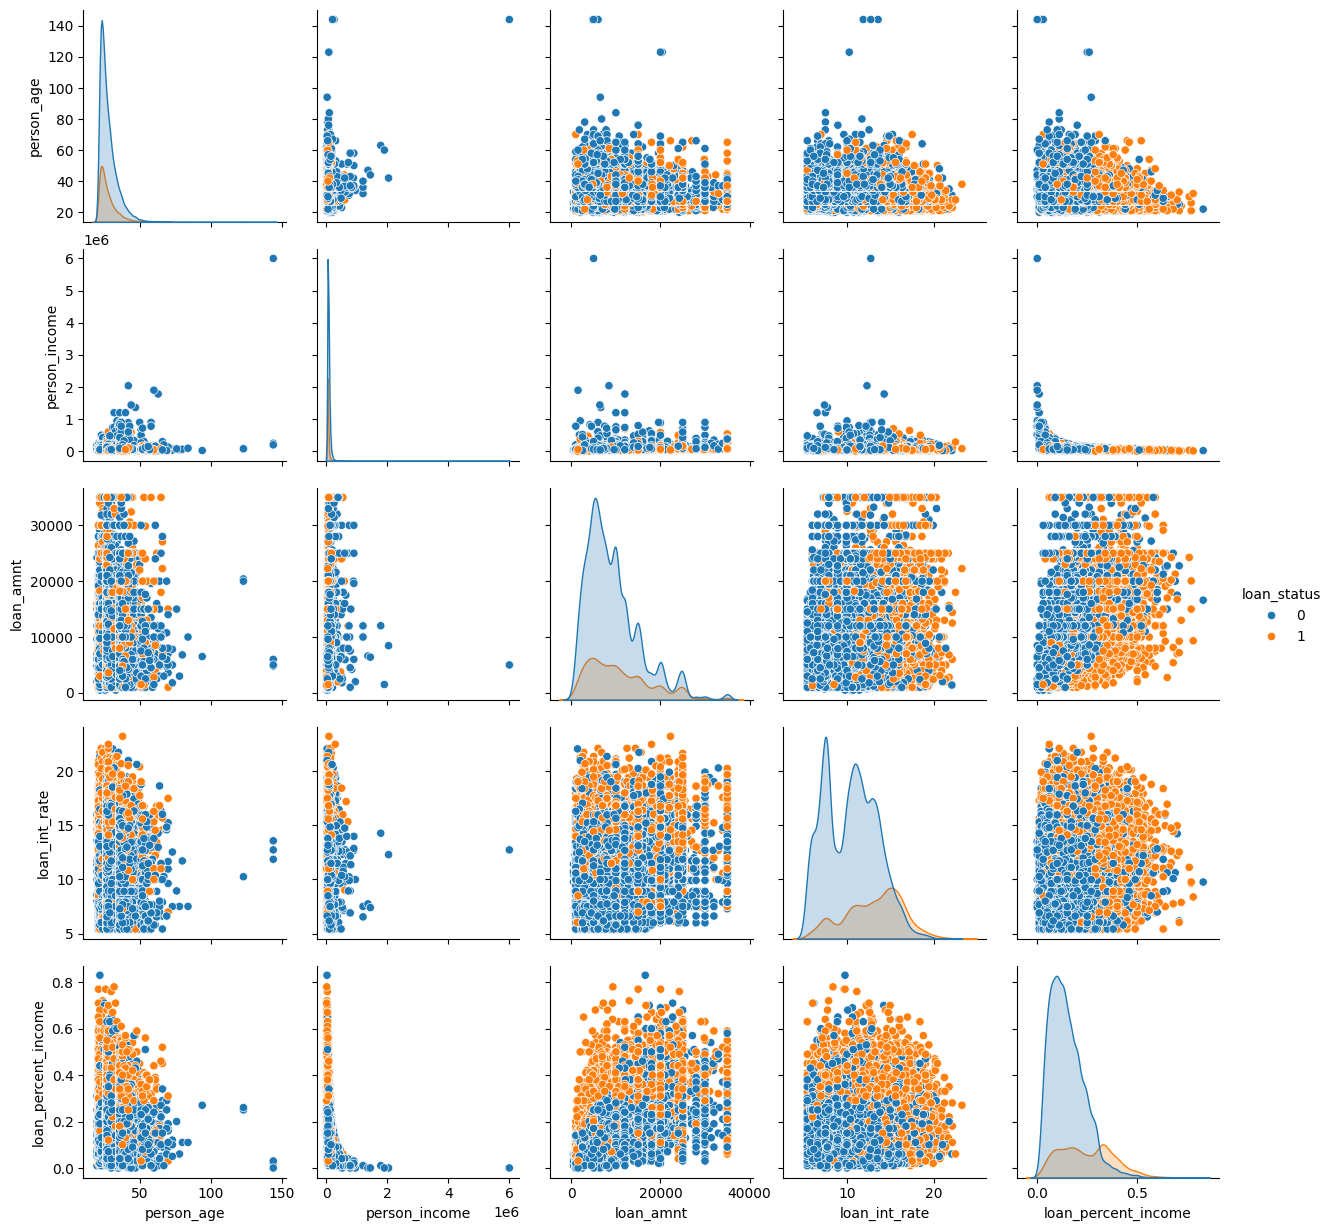

In [30]:
sns.pairplot(
    df[['person_age',
        'person_income',
        'loan_amnt',
        'loan_int_rate',
        'loan_percent_income',
        'loan_status']],
    hue='loan_status'
)

plt.show()

In [31]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,887
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3095
loan_status,0
loan_percent_income,0


In [32]:
# Fill missing values with median
df["person_emp_length"].fillna(df["person_emp_length"].median(), inplace=True)
df["loan_int_rate"].fillna(df["loan_int_rate"].median(), inplace=True)

In [33]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


In [34]:
cat_cols

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')

In [35]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

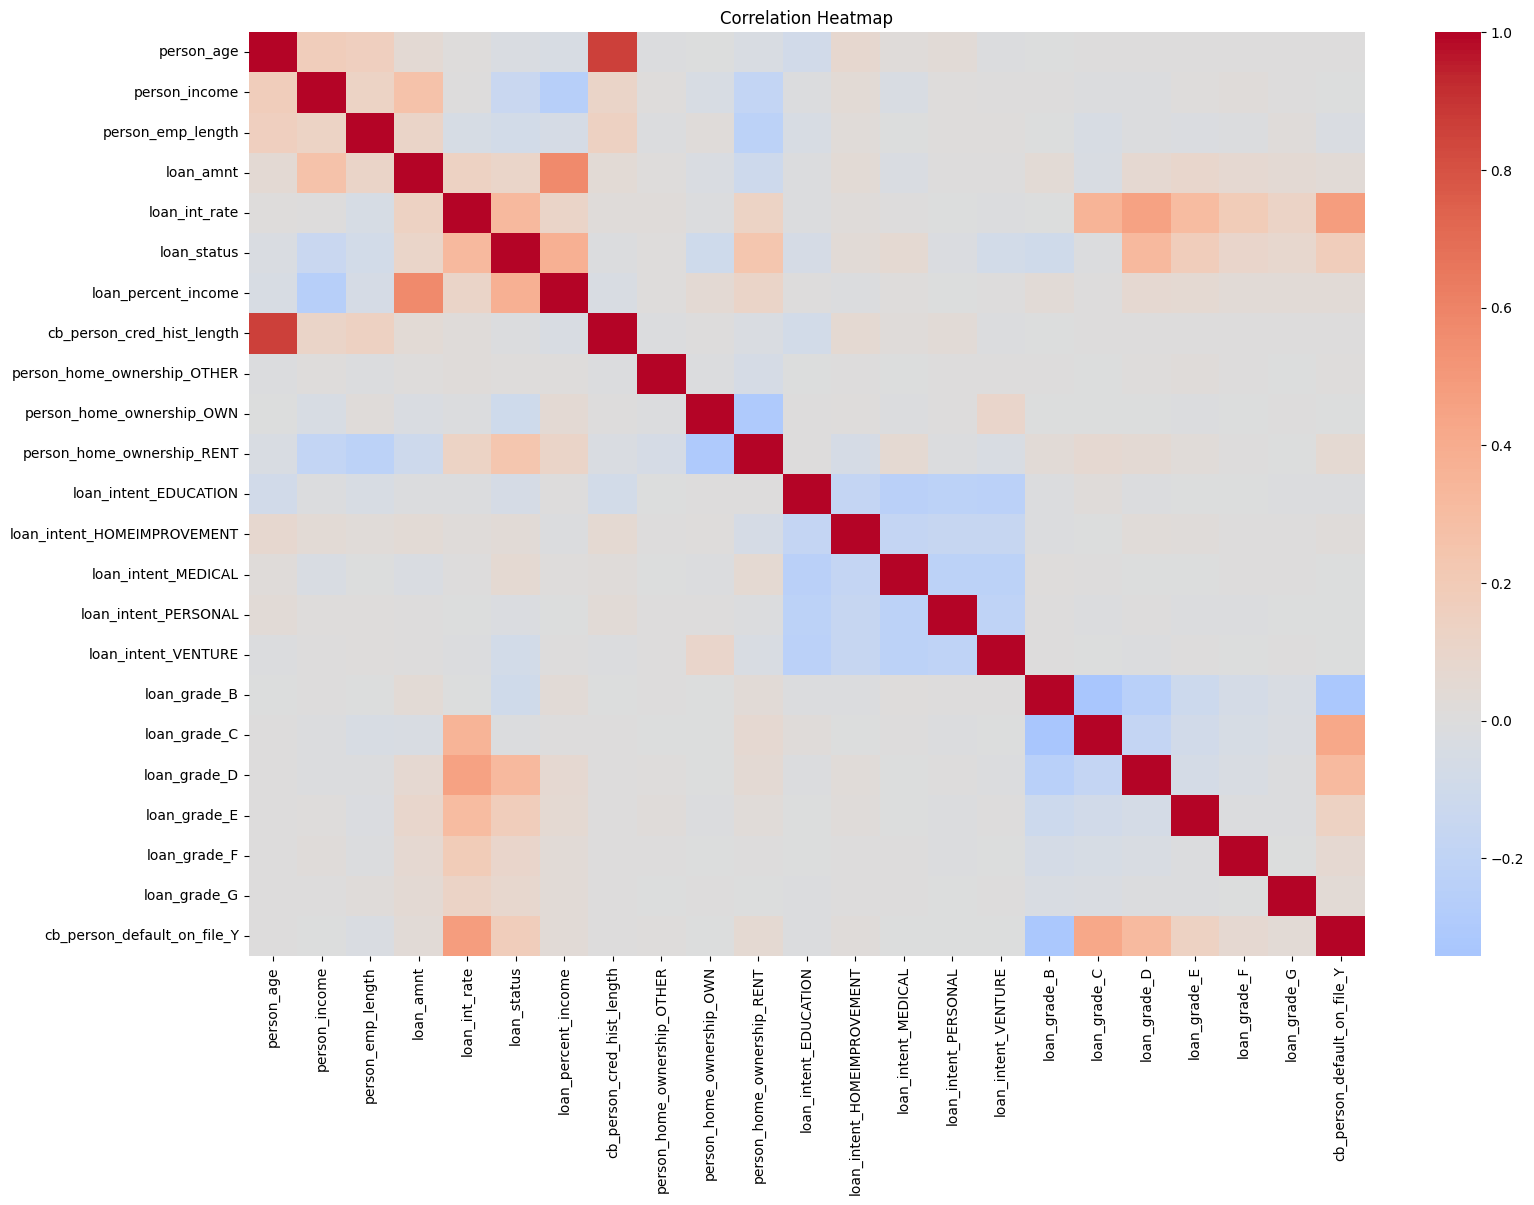

In [36]:
plt.figure(figsize=(18,12))

sns.heatmap(df.corr(),
            cmap="coolwarm",
            center=0)

plt.title("Correlation Heatmap")
plt.show()

In [37]:
corr = df.corr()["loan_status"].sort_values(ascending=False)
print(corr)

loan_status                    1.000000
loan_percent_income            0.379697
loan_int_rate                  0.320081
loan_grade_D                   0.319016
person_home_ownership_RENT     0.238132
loan_grade_E                   0.180402
cb_person_default_on_file_Y    0.179385
loan_amnt                      0.105736
loan_grade_F                   0.101904
loan_grade_G                   0.082388
loan_intent_MEDICAL            0.056667
loan_intent_HOMEIMPROVEMENT    0.036613
person_home_ownership_OTHER    0.012836
loan_grade_C                  -0.013453
cb_person_cred_hist_length    -0.016498
loan_intent_PERSONAL          -0.021546
person_age                    -0.022698
loan_intent_EDUCATION         -0.055461
loan_intent_VENTURE           -0.078238
person_emp_length             -0.082517
loan_grade_B                  -0.092203
person_home_ownership_OWN     -0.101916
person_income                 -0.145005
Name: loan_status, dtype: float64


In [38]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [41]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

In [44]:
results = []

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Probability for ROC-AUC
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

In [45]:
results_df = pd.DataFrame(results)

results_df.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.931832,0.951017,0.725670,0.823200,0.930553
1,Decision Tree,0.891733,0.742547,0.772920,0.757429,0.848955
0,Logistic Regression,0.845466,0.733708,0.460508,0.565858,0.847196
3,SVM,0.805984,0.847826,0.137518,0.236650,0.717402


In [46]:
best_model_name = results_df.sort_values(
    by="F1 Score",
    ascending=False
).iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Random Forest


In [47]:
best_model = LogisticRegression(max_iter=1000, random_state=42)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [48]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.95      0.91      5066
           1       0.73      0.46      0.57      1418

    accuracy                           0.85      6484
   macro avg       0.80      0.71      0.74      6484
weighted avg       0.83      0.85      0.83      6484



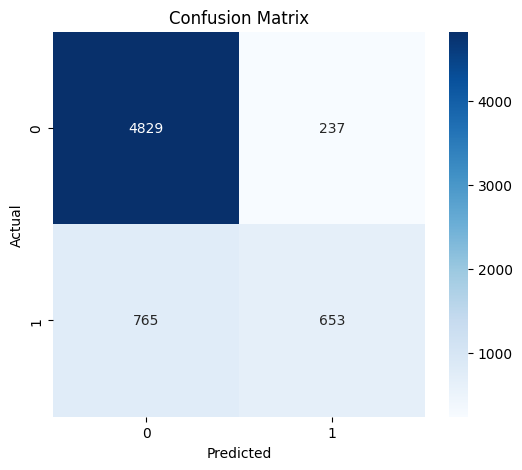

In [49]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [50]:
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

ROC-AUC Score: 0.8471958581143574


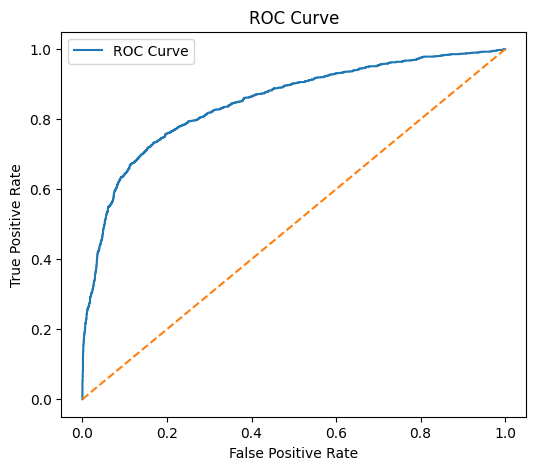

In [51]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [52]:
import joblib

joblib.dump(best_model, "credit_scoring_model.pkl")

['credit_scoring_model.pkl']